# Laboratorio 5: Clasificacion de tweets sobre desastres
## CC3084 -- Data Science -- UVG -- Semestre II 2026

**Objetivo:** Determinar si un tweet se refiere a un desastre real (`target=1`) o no (`target=0`).

**Dataset:** [NLP with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started) (Kaggle).

> **Nota metodologica:** Un avance preliminar utilizo `test.csv` y una etiqueta proxy (`keyword_present`) que produjo una accuracy aparentemente alta. Esa clasificacion no corresponde al objetivo del laboratorio y fue corregida. Este notebook trabaja con `train.csv` y la etiqueta real `target`.

## 0. Configuracion

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from analisis_lab5 import (
    SEED, STOPWORDS, NEGATIONS, CLASS_LABELS, CLASS_COLORS,
    OUTPUT_DIR, TABLES_DIR, MODELS_DIR, ensure_dirs, ensure_model_dirs,
    load_datasets, validate_schemas,
    clean_for_analysis, remove_stopwords_text, clean_for_model, decode_keyword,
    preprocess_dataframe, add_text_features, audit_duplicates,
    plot_target_distribution, plot_missing_values, plot_text_lengths,
    plot_feature_counts, plot_keyword_frequency,
    plot_disaster_rate_by_keyword, plot_top_locations,
    compute_ngrams, ngram_table_by_class, plot_ngrams_by_class,
    save_ngram_tables, show_distinctive_ngrams,
    generate_wordcloud_for_class, generate_all_wordclouds,
    create_group_stratified_split, get_model_configs,
    clasificar_tweet, TextCleaner,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})
ensure_dirs(); ensure_model_dirs()
print(f"Semilla global: {SEED}")
print(f"Stopwords: {len(STOPWORDS)} (negaciones excluidas: {len(NEGATIONS)})")

Semilla global: 42
Stopwords: 306 (negaciones excluidas: 43)


## 1. Descripcion y validacion de los datos

In [2]:
train, test, submission = load_datasets()
print(f"train.csv:  {train.shape[0]:,} x {train.shape[1]}, cols={list(train.columns)}")
print(f"test.csv:   {test.shape[0]:,} x {test.shape[1]}, target presente: {'target' in test.columns}")
print(f"submission: {submission.shape[0]:,} x {submission.shape[1]}, IDs coinciden: {(submission['id'].values == test['id'].values).all()}")
print(f"\nSuperposicion IDs train/test: {len(set(train['id']) & set(test['id']))}")

report = validate_schemas(train, test, submission)
print(f"Esquemas validos: {report['valid']}")

train.csv:  7,613 x 5, cols=['id', 'keyword', 'location', 'text', 'target']
test.csv:   3,263 x 4, target presente: False
submission: 3,263 x 2, IDs coinciden: True

Superposicion IDs train/test: 0
Esquemas validos: True


In [3]:
profile = pd.DataFrame({
    "Tipo": train.dtypes.astype(str),
    "Nulos": train.isna().sum(),
    "% Nulos": (train.isna().mean() * 100).round(2),
    "Unicos": train.nunique(),
})
profile

,Tipo,Nulos,% Nulos,Unicos
id,int64,0,0.00,7613
keyword,object,61,0.80,221
location,object,2533,33.27,3341
text,object,0,0.00,7503
target,int64,0,0.00,2


**Interpretacion:** 7,613 tweets, IDs unicos, texto completo, `location` con 3,341 valores unicos y 33% faltante. `keyword` tiene 61 faltantes.

## 2. Preprocesamiento

| Nivel | Columna | Uso |
|-------|---------|-----|
| Original | `text` | Ejemplos, sentimiento |
| Analisis | `text_clean` | Exploracion |
| Sin stopwords | `text_no_stop` | Frecuencias, n-gramas |
| Modelo | `text_model` | TF-IDF posterior |

Decisiones clave: `#earthquake` -> `earthquake`, apostrofos colapsados (`don't` -> `dont`), 911 conservado, stopwords de sklearn menos negaciones, sin stemming.

In [4]:
train = preprocess_dataframe(train)
train = add_text_features(train)
print(f"Textos vacios tras limpieza: {(train['text_clean'] == '').sum()}")
# Demostracion
for tc in ["#earthquake is scary", "Heard about #wildfire near #LA", "#911 call"]:
    print(f"  '{tc}' -> '{clean_for_analysis(tc)}'")

Textos vacios tras limpieza: 0
  '#earthquake is scary' -> 'earthquake is scary'
  'Heard about #wildfire near #LA' -> 'heard about wildfire near la'
  '#911 call' -> '911 call'


In [5]:
encoded_kw = train[train["keyword"].str.contains("%", na=False)]["keyword"].unique()[:8]
pd.DataFrame({"original": encoded_kw, "decoded": [decode_keyword(k) for k in encoded_kw]})

,original,decoded
0,airplane%20accident,airplane accident
1,blew%20up,blew up
2,blown%20up,blown up
3,body%20bag,body bag
4,body%20bagging,body bagging
5,body%20bags,body bags
6,bridge%20collapse,bridge collapse
7,buildings%20burning,buildings burning


## 3. Auditoria de textos repetidos

Se reportan duplicados con dos criterios: exacto y normalizado (`strip().lower()`). La clave normalizada se usa para agrupar particiones y evitar fuga.

In [6]:
exact = audit_duplicates(train, method="exact")
norm = audit_duplicates(train, method="normalized")
print("Duplicados exactos:")
print(f"  Grupos: {exact['n_duplicate_groups']}, Filas: {exact['n_duplicate_rows']}")
print(f"  Contradicciones: {exact['n_contradictory_groups']} grupos / {exact['n_contradictory_rows']} filas")
print("\nDuplicados normalizados (strip+lower):")
print(f"  Grupos: {norm['n_duplicate_groups']}, Filas: {norm['n_duplicate_rows']}")
print(f"  Contradicciones: {norm['n_contradictory_groups']} grupos / {norm['n_contradictory_rows']} filas")

Duplicados exactos:
  Grupos: 69, Filas: 179
  Contradicciones: 18 grupos / 55 filas

Duplicados normalizados (strip+lower):
  Grupos: 69, Filas: 180
  Contradicciones: 18 grupos / 56 filas


In [7]:
contra = norm["contradictions"]
if len(contra) > 0:
    shown = 0
    for _, grp in contra.groupby(contra["text"].str.strip().str.lower()):
        if shown >= 4: break
        print(f"Texto: '{grp['text'].iloc[0][:80]}'")
        print(f"  Etiquetas: {grp['target'].tolist()}, IDs: {grp['id'].tolist()}\n")
        shown += 1

Texto: '#Allah describes piling up #wealth thinking it would last #forever as the descri'
  Etiquetas: [0, 0, 1], IDs: [6094, 6105, 6123]

Texto: '#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsaf'
  Etiquetas: [1, 1, 0], IDs: [5996, 6023, 6031]

Texto: '.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally '
  Etiquetas: [1, 1, 0, 1], IDs: [4068, 4072, 4076, 4077]

Texto: 'Caution: breathing may be hazardous to your health.'
  Etiquetas: [1, 0], IDs: [6012, 6017]



**Decisiones para modelado:**
1. Todos los registros del mismo grupo textual en la misma particion (GroupStratifiedKFold).
2. Etiquetas contradictorias = ruido irreducible; no se eliminan.
3. La diferencia entre duplicados exactos (179 filas) y normalizados (180 filas) se debe a 1 texto con espacios extra.

## 4. Analisis exploratorio

### 4.1 Distribucion de target

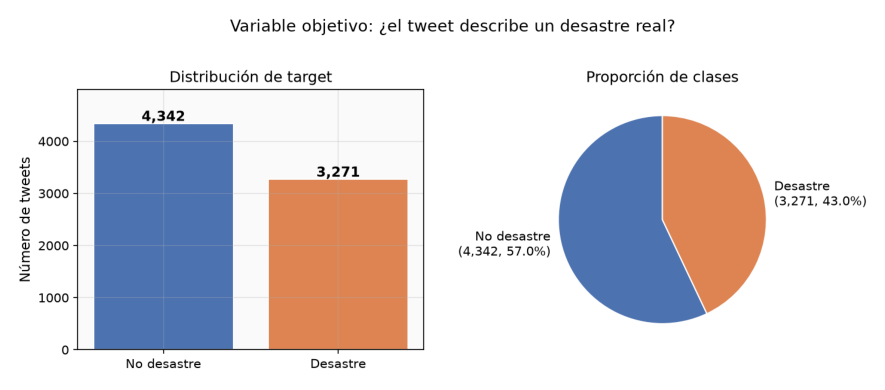

No desastre: 4,342 (57.0%), Desastre: 3,271 (43.0%), Ratio: 1.33


In [8]:
plot_target_distribution(train)
img = plt.imread(OUTPUT_DIR / "target_distribution.png")
fig, ax = plt.subplots(figsize=(10, 4)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
counts = train["target"].value_counts().sort_index()
print(f"No desastre: {counts[0]:,} ({counts[0]/len(train)*100:.1f}%), Desastre: {counts[1]:,} ({counts[1]/len(train)*100:.1f}%), Ratio: {counts[0]/counts[1]:.2f}")

### 4.2 Valores faltantes

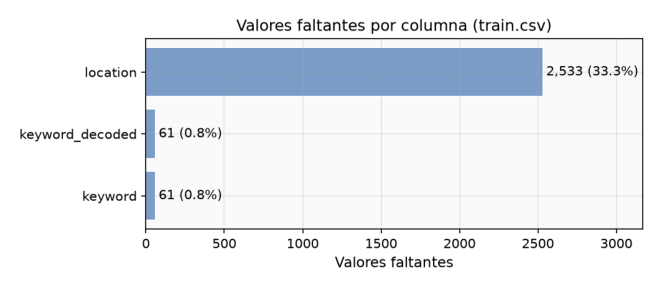

In [9]:
plot_missing_values(train)
img = plt.imread(OUTPUT_DIR / "missing_values.png")
fig, ax = plt.subplots(figsize=(7, 3)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()

### 4.3 Longitud de texto por clase

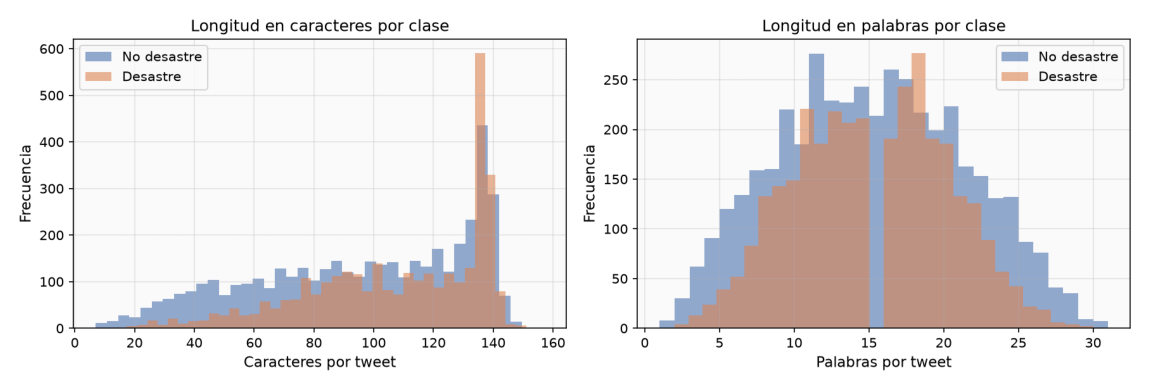

No desastre: chars media=96, words media=14.7
Desastre: chars media=108, words media=15.2


In [10]:
plot_text_lengths(train)
img = plt.imread(OUTPUT_DIR / "text_length_by_target.png")
fig, ax = plt.subplots(figsize=(12, 4)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
for t in [0, 1]:
    s = train[train["target"] == t]
    print(f"{CLASS_LABELS[t]}: chars media={s['char_count'].mean():.0f}, words media={s['word_count'].mean():.1f}")

### 4.4 Elementos de texto por clase

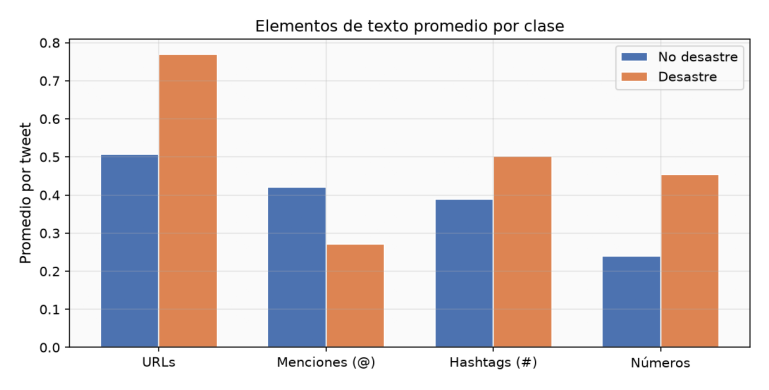

In [11]:
plot_feature_counts(train)
img = plt.imread(OUTPUT_DIR / "feature_counts_by_target.png")
fig, ax = plt.subplots(figsize=(8, 4)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()

### 4.5 Keywords y tasa de desastre

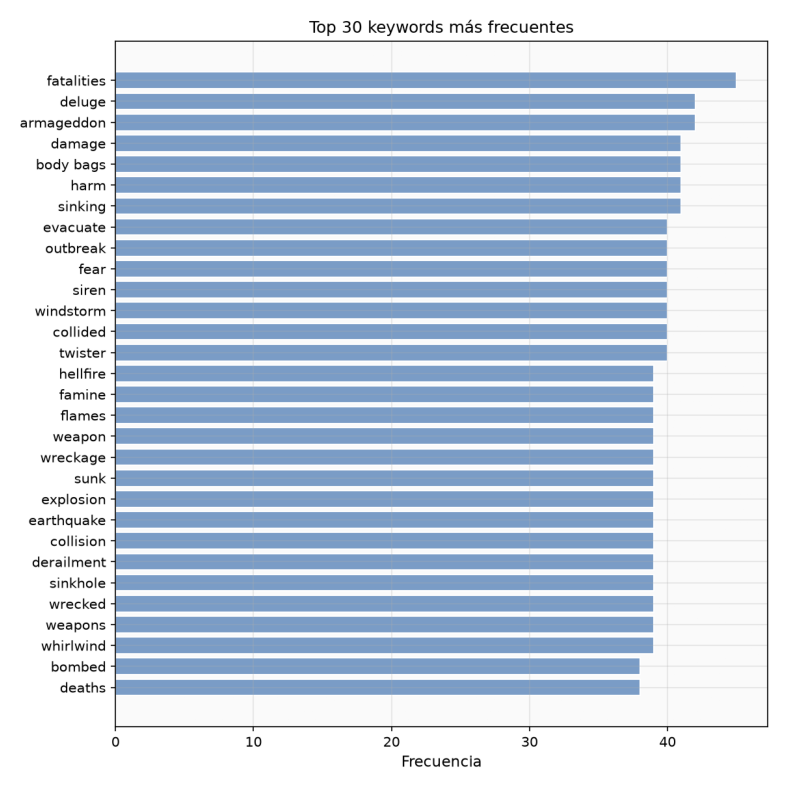

In [12]:
plot_keyword_frequency(train)
img = plt.imread(OUTPUT_DIR / "keyword_top30.png")
fig, ax = plt.subplots(figsize=(8, 8)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()

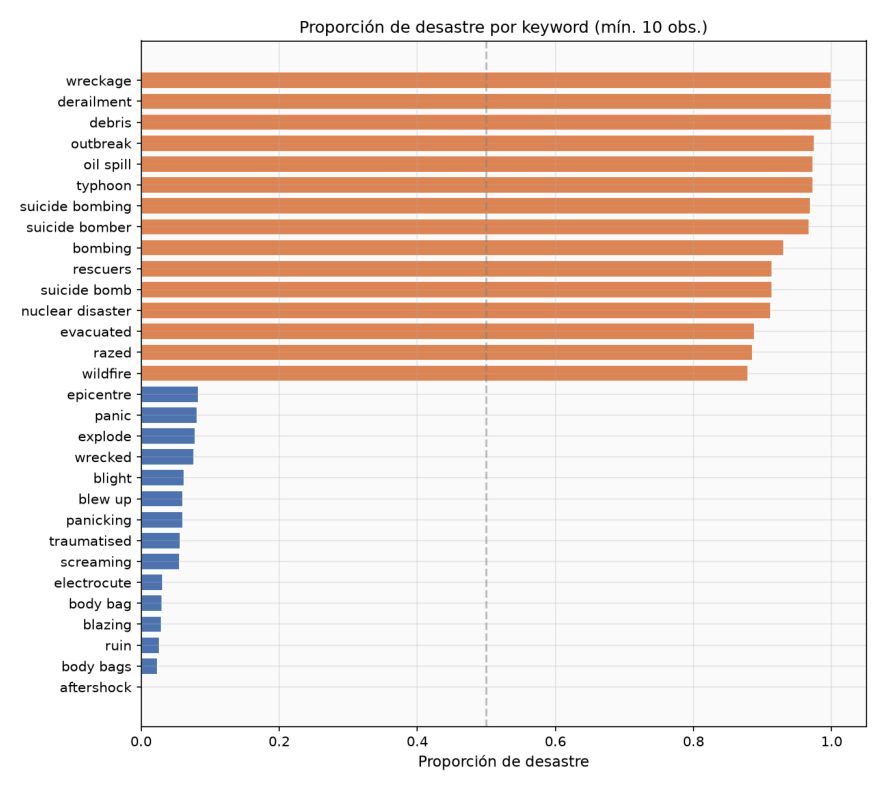

In [13]:
plot_disaster_rate_by_keyword(train, min_obs=10)
img = plt.imread(OUTPUT_DIR / "disaster_rate_by_keyword.png")
fig, ax = plt.subplots(figsize=(9, 8)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()

### 4.6 Ubicaciones

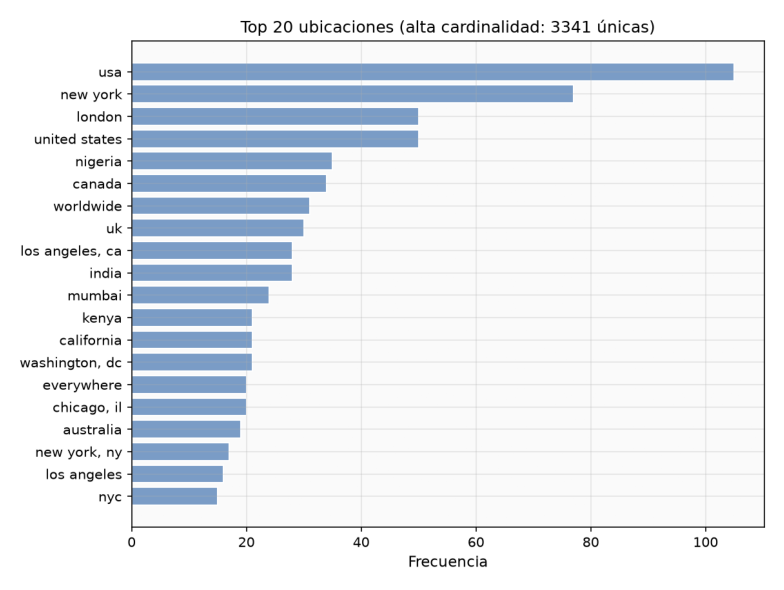

Ubicaciones unicas: 3,341, Faltantes: 2,533 (33.3%)


In [14]:
plot_top_locations(train)
img = plt.imread(OUTPUT_DIR / "top_locations.png")
fig, ax = plt.subplots(figsize=(8, 6)); ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
print(f"Ubicaciones unicas: {train['location'].nunique():,}, Faltantes: {train['location'].isna().sum():,} ({train['location'].isna().mean()*100:.1f}%)")

### 4.7 Ejemplos por clase

In [15]:
for t in [0, 1]:
    print(f"\n=== {CLASS_LABELS[t]} (target={t}) ===")
    for _, r in train[train["target"] == t].sample(4, random_state=SEED).iterrows():
        kw = r["keyword_decoded"] if pd.notna(r["keyword_decoded"]) else "(sin keyword)"
        print(f"  [{kw}] {r['text'][:100]}")


=== No desastre (target=0) ===
  [fatality] Everyday is a near death fatality for me on the road. Thank god is on my side.??
  [hazard] #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://
  [inundated] @Lenn_Len Probably. We are inundated with them most years!
  [siren] A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thi

=== Desastre (target=1) ===
  [floods] Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct
  [armageddon] Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C
  [buildings burning] @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. Th
  [attacked] Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)


## 5. N-gramas

Frecuencias por clase con **log-odds ratio suavizado** (Laplace, alpha=1) como medida de caracter distintivo. Positivo = asociado a desastre.

In [16]:
save_ngram_tables(train)
for n in [1, 2, 3]:
    plot_ngrams_by_class(train, n=n, top_k=20)

  unigrams: 14614 unigrams únicos guardados.

  bigrams: 43949 bigrams únicos guardados.


  trigrams: 41535 trigrams únicos guardados.


In [17]:
for n, name in [(1, "unigrams"), (2, "bigrams"), (3, "trigrams")]:
    table = pd.read_csv(TABLES_DIR / f"{name}_by_class.csv")
    d = show_distinctive_ngrams(table, top_k=10)
    print(f"\n{'='*50}")
    print(f"{name.upper()} mas distintivos (frecuencia minima = 5)")
    print(f"{'='*50}")
    print(f"\nDESASTRE (log-odds > 0):")
    print(d["disaster"][["ngram", "freq_desastre", "freq_no_desastre", "log_odds"]].to_string(index=False))
    print(f"\nNO DESASTRE (log-odds < 0):")
    print(d["no_disaster"][["ngram", "freq_desastre", "freq_no_desastre", "log_odds"]].to_string(index=False))


UNIGRAMS mas distintivos (frecuencia minima = 5)

DESASTRE (log-odds > 0):
        ngram  freq_desastre  freq_no_desastre  log_odds
        mh370             72                 0    4.3904
     northern             64                 0    4.2743
 legionnaires             62                 0    4.2431
       debris             50                 0    4.0318
       severe             47                 0    3.9711
    hiroshima             91                 1    3.9286
     migrants             41                 0    3.8376
   derailment             41                 0    3.8376
investigators             37                 0    3.7375
       mosque             36                 0    3.7109

NO DESASTRE (log-odds < 0):
      ngram  freq_desastre  freq_no_desastre  log_odds
       bags              1                43   -2.9911
        bag              1                40   -2.9205
 aftershock              0                19   -2.8958
       ruin              1                37   -

**Interpretacion:** Bigramas y trigramas desambiguan mejor que unigramas (e.g., `fire` es ambiguo pero `forest fire` es claramente desastre). Terminos como `fire`, `crash`, `storm` aparecen en ambas clases por uso figurativo.

## 6. Nubes de palabras

El tamano representa frecuencia dentro de la clase, **no capacidad predictiva**.

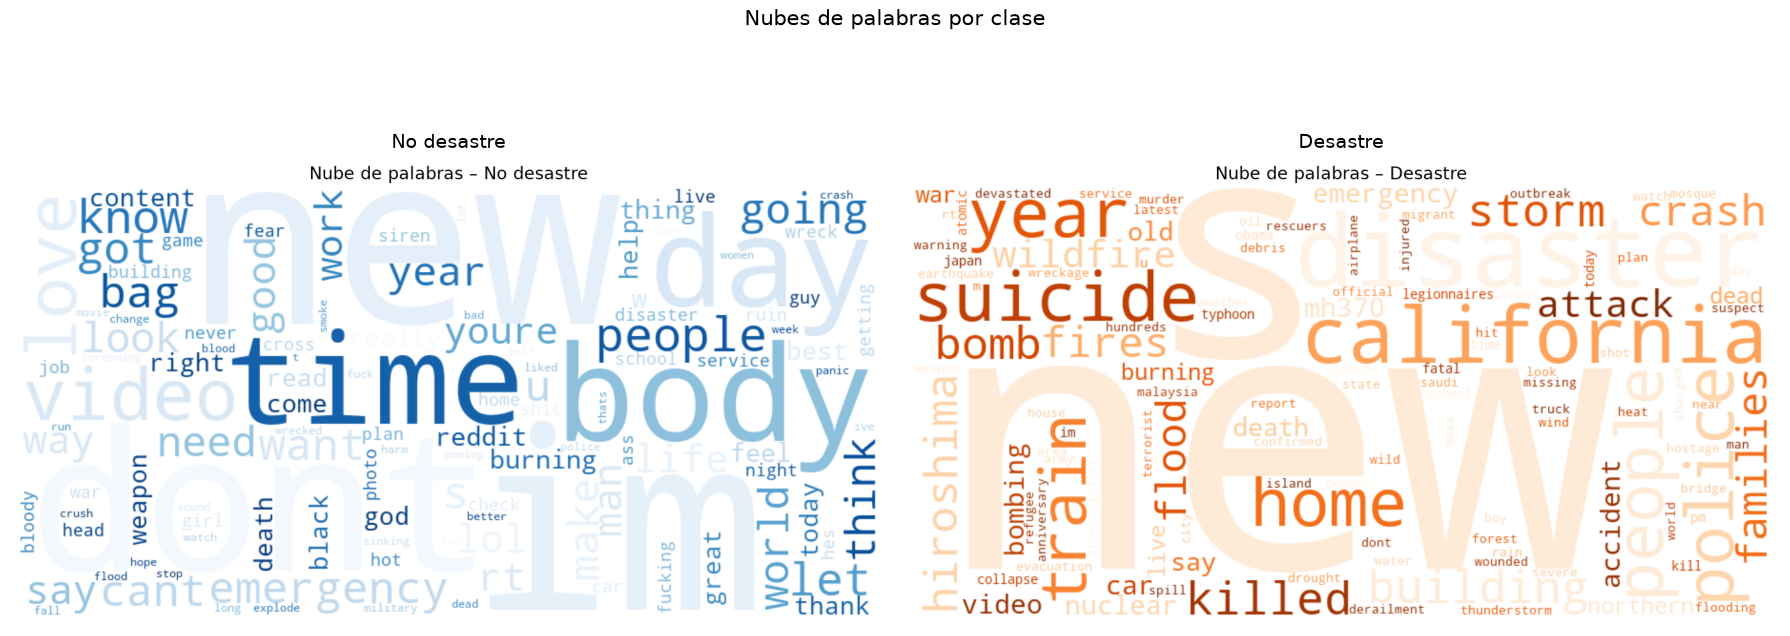

In [18]:
generate_all_wordclouds(train)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for idx, t in enumerate([0, 1]):
    img = plt.imread(OUTPUT_DIR / f"wordcloud_target{t}.png")
    axes[idx].imshow(img); axes[idx].axis("off")
    axes[idx].set_title(CLASS_LABELS[t], fontsize=14)
fig.suptitle("Nubes de palabras por clase", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

## 7. Modelado

### 7.1 Division dev/holdout estratificada por grupos

Se reserva ~20% como holdout usando `StratifiedGroupKFold`. El mismo texto normalizado nunca aparece en ambas particiones. El modelo usa **solo el texto crudo** (sin `id`, `keyword` ni `location`), porque la funcion final recibira unicamente un tweet.

In [19]:
X = train["text"].values
y = train["target"].values
groups = train["text"].str.strip().str.lower().values

sp = create_group_stratified_split(X, y, groups)
print(f"Dev:     {len(sp['X_dev']):,} ({len(sp['X_dev'])/len(X)*100:.1f}%)")
print(f"Holdout: {len(sp['X_hold']):,} ({len(sp['X_hold'])/len(X)*100:.1f}%)")
print(f"Grupos dev:     {len(set(sp['groups_dev'])):,}")
print(f"Grupos holdout: {len(set(sp['groups_hold'])):,}")
print(f"Grupos compartidos: {sp['shared_groups']}")
print(f"\nDev target:     {pd.Series(sp['y_dev']).value_counts().sort_index().to_dict()}")
print(f"Holdout target: {pd.Series(sp['y_hold']).value_counts().sort_index().to_dict()}")

Dev:     6,090 (80.0%)
Holdout: 1,523 (20.0%)
Grupos dev:     6,003
Grupos holdout: 1,499
Grupos compartidos: 0

Dev target:     {0: 3473, 1: 2617}
Holdout target: {0: 869, 1: 654}


### 7.2 Comparacion de modelos

Se comparan 5 configuraciones con CV estratificado por grupos (5 folds). Metrica principal: **F1 de target=1**. Secundaria: **PR-AUC**.

| Modelo | Descripcion |
|--------|-------------|
| Dummy | Baseline: predice clase mayoritaria |
| LogReg | Regresion Logistica con class_weight=balanced |
| ComplementNB | Complement Naive Bayes |
| LinearSVC | SVM lineal calibrado (CalibratedClassifierCV) |
| LogReg_char | LogReg con n-gramas de caracteres (3-5) |

Todos usan `TextCleaner` -> `TfidfVectorizer` -> clasificador dentro de un `Pipeline` para evitar fuga de datos.

In [20]:
import json
from analisis_lab5 import run_models

# Si ya se ejecuto --models, cargar resultados; si no, entrenar
cv_path = MODELS_DIR / "cv_comparison.csv"
if cv_path.exists():
    cv_df = pd.read_csv(cv_path)
    print("Resultados CV cargados desde disco:")
else:
    run_models()
    cv_df = pd.read_csv(cv_path)
    print("Modelos entrenados y evaluados:")

cv_df

Resultados CV cargados desde disco:


,model,params,f1_disaster,pr_auc,roc_auc,precision,recall,accuracy,f1_macro
0,LogReg_char,{'clf__C': 0.5},0.7631,0.8591,0.8642,0.7752,0.7512,0.7995,0.7946
1,LogReg,"{'clf__C': 5.0, 'tfidf__max_df': 0.9}",0.7541,0.8501,0.8584,0.7681,0.7405,0.7924,0.7873
2,LinearSVC,"{'clf__estimator__C': 0.5, 'tfidf__max_df': 0.9}",0.7516,0.8433,0.8563,0.7899,0.7169,0.7964,0.7895
3,ComplementNB,"{'clf__alpha': 0.5, 'tfidf__max_df': 0.9}",0.7436,0.8520,0.8518,0.8125,0.6855,0.7969,0.7877
4,Dummy,{},0.0000,0.4297,0.5000,0.0000,0.0000,0.5703,0.3632


### 7.3 Evaluacion en holdout

In [21]:
metrics_path = MODELS_DIR / "holdout_metrics.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        metrics = json.load(f)
    print("Metricas del holdout (evaluacion unica):")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
else:
    print("Ejecutar --models primero para generar metricas de holdout.")

Metricas del holdout (evaluacion unica):
  f1_disaster: 0.7894
  precision: 0.8057
  recall: 0.7737
  accuracy: 0.8227
  f1_macro: 0.8182
  pr_auc: 0.8786
  roc_auc: 0.8784


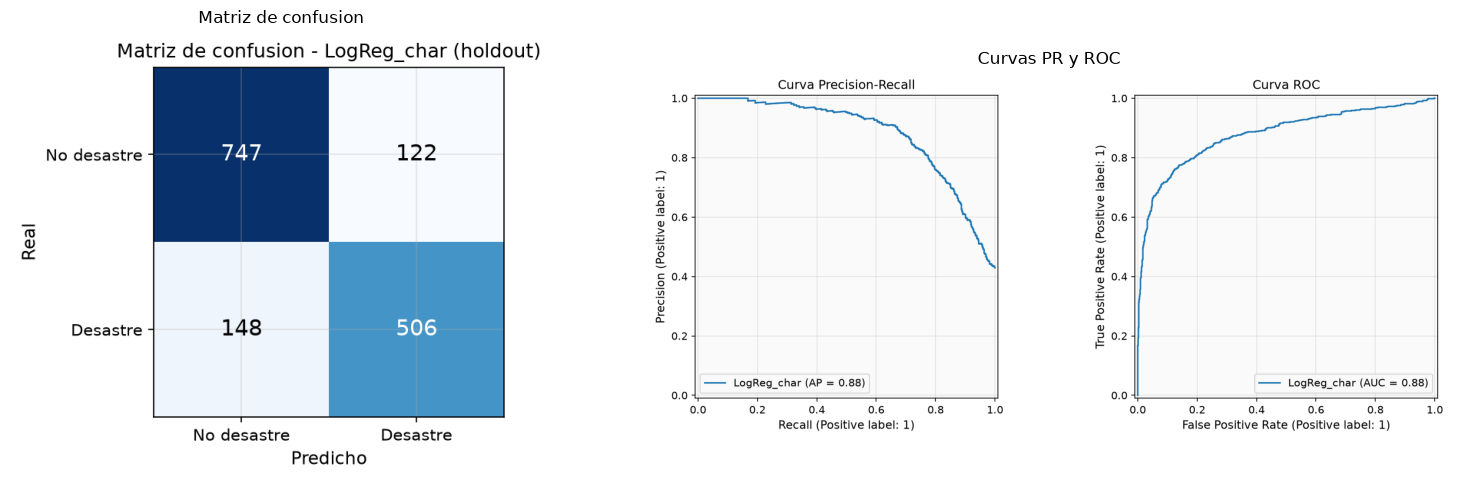

In [22]:
cm_path = MODELS_DIR / "confusion_matrix.png"
pr_path = MODELS_DIR / "pr_roc_curves.png"
if cm_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(plt.imread(cm_path)); axes[0].axis("off"); axes[0].set_title("Matriz de confusion")
    if pr_path.exists():
        axes[1].imshow(plt.imread(pr_path)); axes[1].axis("off"); axes[1].set_title("Curvas PR y ROC")
    plt.tight_layout(); plt.show()

### 7.4 Errores del modelo

In [23]:
fp_path = MODELS_DIR / "false_positives.csv"
fn_path = MODELS_DIR / "false_negatives.csv"
if fp_path.exists():
    fp = pd.read_csv(fp_path)
    fn = pd.read_csv(fn_path)
    print(f"Falsos positivos (predicho desastre, real no desastre): {len(fp)} ejemplos")
    for _, r in fp.head(5).iterrows():
        print(f"  [{r.get('keyword', '')}] {r['text'][:90]}")
    print(f"\nFalsos negativos (predicho no desastre, real desastre): {len(fn)} ejemplos")
    for _, r in fn.head(5).iterrows():
        print(f"  [{r.get('keyword', '')}] {r['text'][:90]}")
else:
    print("Ejecutar --models primero.")

Falsos positivos (predicho desastre, real no desastre): 15 ejemplos
  [accident] mom: 'we didn't get home as fast as we wished' 
me: 'why is that?'
mom: 'there was an acci
  [aftershock] 'The harder the conflict the more glorious the triumph.' Thomas Paine
  [airplane%20accident] Statistically I'm at more of risk of getting killed by a cop than I am of dying in an airp
  [army] WWI WWII JAPANESE ARMY NAVY MILITARY JAPAN LEATHER WATCH WAR MIDO WW1 2 - Full read by eBa
  [attack] Demi stans really think Heart Attack sold 5/6 million copies ??

Falsos negativos (predicho no desastre, real desastre): 15 ejemplos
  [annihilated] @TomcatArts thus explaining why you were all annihilated. But the few or in this case you 
  [annihilation] @willienelson We need help! Horses will die!Please RT &amp; sign petition!Take a stand &am
  [annihilation] World Annihilation vs Self Transformation http://t.co/pyehwodWun Aliens Attack to Extermin
  [apocalypse] I know it's a question of interpretation but t

## 8. Funcion de clasificacion

`clasificar_tweet(texto)` recibe texto sin procesar y retorna clase, interpretacion y score.

In [24]:
# Demo con el modelo guardado (si existe)
import joblib
model_path = MODELS_DIR / "best_pipeline.joblib"
if model_path.exists():
    pipe = joblib.load(model_path)
    test_tweets = [
        "BREAKING: Earthquake hits California, buildings collapsed",
        "I love this song it's fire",
        "Flood warning issued for the entire coast",
        "My phone battery just died lol",
        "911 emergency services overwhelmed by hurricane damage",
        "",
    ]
    for tw in test_tweets:
        r = clasificar_tweet(tw, pipeline=pipe)
        print(f"'{tw[:60]}...' " if len(tw) > 60 else f"'{tw}' ")
        print(f"  -> {r['interpretacion']} (score={r['score']}, tipo={r['score_tipo']})\n")
else:
    print("Modelo no encontrado. Ejecutar --models primero.")

'BREAKING: Earthquake hits California, buildings collapsed' 
  -> Desastre (score=0.9248, tipo=probabilidad)

'I love this song it's fire' 
  -> No desastre (score=0.3028, tipo=probabilidad)

'Flood warning issued for the entire coast' 
  -> Desastre (score=0.7831, tipo=probabilidad)

'My phone battery just died lol' 
  -> No desastre (score=0.1904, tipo=probabilidad)

'911 emergency services overwhelmed by hurricane damage' 
  -> Desastre (score=0.7334, tipo=probabilidad)

'' 
  -> Entrada invalida (score=None, tipo=None)



## 9. Prediccion de test.csv

Tras la evaluacion honesta, se reentrena con todo `train.csv` y se predice `test.csv`. Ejecutar:

```
python analisis_lab5.py --predict-test
```

In [25]:
sub_path = Path("submission_lab5.csv")
if sub_path.exists():
    sub = pd.read_csv(sub_path)
    sample = pd.read_csv("sample_submission.csv")
    print(f"Filas: {len(sub)}")
    print(f"Columnas: {list(sub.columns)}")
    print(f"IDs coinciden: {(sub['id'].values == sample['id'].values).all()}")
    print(f"Distribucion: {sub['target'].value_counts().sort_index().to_dict()}")
else:
    print("Ejecutar --predict-test para generar submission_lab5.csv")

Filas: 3263
Columnas: ['id', 'target']
IDs coinciden: True
Distribucion: {0: 1928, 1: 1335}


## 11. Analisis de sentimiento (Fase 3)

Se aplica VADER sobre el texto **original sin limpiar**, preservando mayusculas, negaciones, puntuacion y emoticonos. VADER fue disenado para texto informal de redes sociales: las mayusculas amplifican la valencia, la puntuacion (`!!!`) refuerza la intensidad, los emoticonos (`:)`, `:(`) tienen scores propios en el lexico, y las negaciones (`not good`) invierten la polaridad del siguiente token. Eliminar estos elementos degradaria la calidad del analisis.

Variables generadas por tweet:
- Scores `neg`, `neu`, `pos`, `compound`
- Etiqueta: positiva (`compound >= 0.05`), negativa (`<= -0.05`), neutra
- `negativity` = score `neg`
- Conteos de tokens reconocidos como positivos/negativos por el lexico (tokens sin polaridad reconocida no se clasifican como neutrales)

In [26]:
from analisis_lab5 import (
    compute_sentiment, SENTIMENT_DIR, CLASS_LABELS, CLASS_COLORS,
    FIG_DPI,
)
import json

sent = compute_sentiment(train)
result = pd.concat([train, sent], axis=1)
print(f"Scores calculados para {len(result)} tweets")
result[["text", "neg", "neu", "pos", "compound",
        "sentiment_label", "negativity",
        "n_positive_tokens", "n_negative_tokens"]].head(10)

Scores calculados para 7613 tweets


,text,neg,neu,pos,compound,sentiment_label,negativity,n_positive_tokens,n_negative_tokens
0,Our Deeds are the Reason of this #earthquake M...,0.000,0.851,0.149,0.2732,positiva,0.000,1,0
1,Forest fire near La Ronge Sask. Canada,0.286,0.714,0.000,-0.3400,negativa,0.286,0,1
2,All residents asked to 'shelter in place' are ...,0.095,0.905,0.000,-0.2960,negativa,0.095,0,1
3,"13,000 people receive #wildfires evacuation or...",0.000,1.000,0.000,0.0000,neutra,0.000,0,0
4,Just got sent this photo from Ruby #Alaska as ...,0.000,1.000,0.000,0.0000,neutra,0.000,0,0
5,#RockyFire Update => California Hwy. 20 closed...,0.124,0.876,0.000,-0.3400,negativa,0.124,0,1
6,#flood #disaster Heavy rain causes flash flood...,0.240,0.760,0.000,-0.6249,negativa,0.240,0,0
7,I'm on top of the hill and I can see a fire in...,0.140,0.756,0.105,-0.1531,negativa,0.140,1,1
8,There's an emergency evacuation happening now ...,0.191,0.809,0.000,-0.3818,negativa,0.191,0,1
9,I'm afraid that the tornado is coming to our a...,0.000,1.000,0.000,0.0000,neutra,0.000,0,0


### 11.1 Distribucion de sentimiento

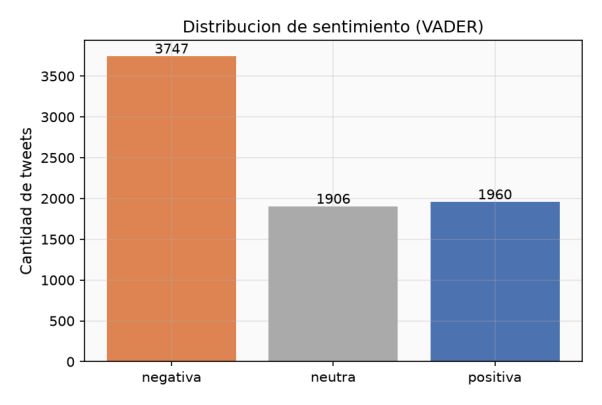

In [27]:
sent_path = SENTIMENT_DIR / "sentiment_distribution.png"
if sent_path.exists():
    img = plt.imread(sent_path)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(img); ax.axis('off')
    plt.show()
else:
    dist = result["sentiment_label"].value_counts()
    print(dist)

### 11.2 Sentimiento por target

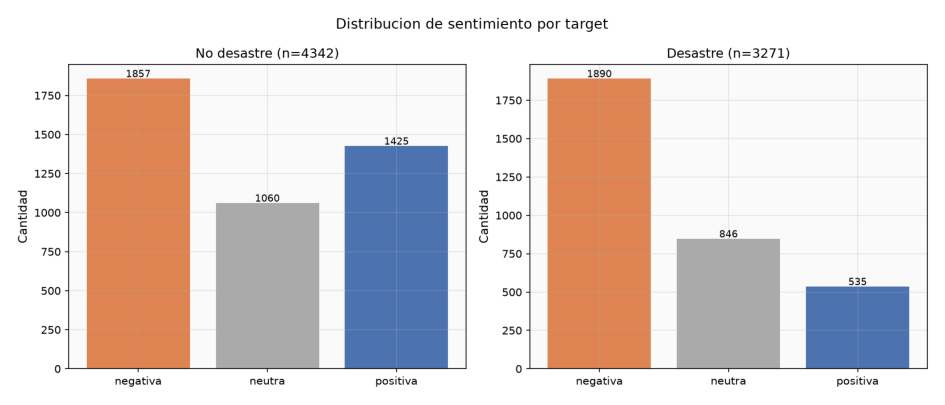

In [28]:
by_target_path = SENTIMENT_DIR / "sentiment_by_target.png"
if by_target_path.exists():
    img = plt.imread(by_target_path)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img); ax.axis('off')
    plt.show()
else:
    ct = pd.crosstab(result['target'].map(CLASS_LABELS),
                     result['sentiment_label'])
    print(ct)

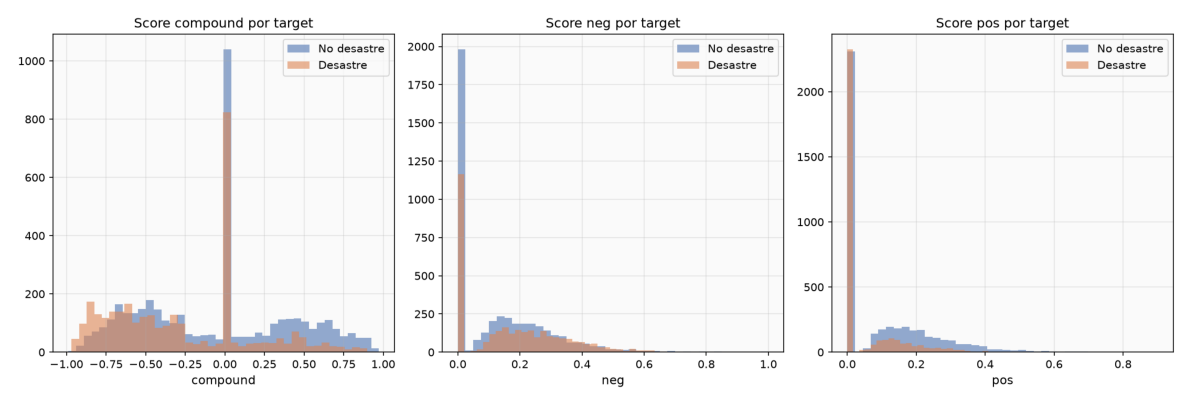

In [29]:
scores_path = SENTIMENT_DIR / "score_distributions.png"
if scores_path.exists():
    img = plt.imread(scores_path)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(img); ax.axis('off')
    plt.show()

### 11.3 Tweets mas negativos y positivos

In [30]:
neg_path = SENTIMENT_DIR / "top10_negative.csv"
pos_path = SENTIMENT_DIR / "top10_positive.csv"
if neg_path.exists():
    print("=== 10 tweets mas negativos ===")
    display(pd.read_csv(neg_path))
if pos_path.exists():
    print("\n=== 10 tweets mas positivos ===")
    display(pd.read_csv(pos_path))

=== 10 tweets mas negativos ===


,id,text,target,compound,sentiment_label
0,10689,wreck? wreck wreck wreck wreck wreck wreck wre...,0,-0.9883,negativa
1,9172,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...,1,-0.9686,negativa
2,9166,Suicide bomber kills 15 in Saudi security site...,1,-0.9623,negativa
3,9137,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,1,-0.9595,negativa
4,9782,@dramaa_llama but otherwise i will stay trappe...,0,-0.9556,negativa
5,9159,17 killed in SÛªArabia mosque suicide bombing...,1,-0.9552,negativa
6,4213,at the lake \n*sees a dead fish*\nme: poor lit...,0,-0.9549,negativa
7,682,illegal alien released by Obama/DHS 4 times Ch...,1,-0.9538,negativa
8,2225,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...,1,-0.9524,negativa
9,9940,@cspan #Prez. Mr. President you are the bigges...,1,-0.9493,negativa



=== 10 tweets mas positivos ===


,id,text,target,compound,sentiment_label
0,10028,Check out 'Want Twister Tickets AND A VIP EXPE...,0,0.9730,positiva
1,9345,@thoutaylorbrown I feel like accidents are jus...,0,0.9564,positiva
2,8989,TodayÛªs storm will pass; let tomorrowÛªs li...,1,0.9471,positiva
3,8136,@Zak_Bagans pets r like part of the family. I ...,0,0.9428,positiva
4,4541,@batfanuk we enjoyed the show today. Great fun...,0,0.9423,positiva
5,9710,Maaaaan I love Love Without Tragedy by @rihann...,0,0.9394,positiva
6,8994,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...,0,0.9376,positiva
7,1453,I'm not a Drake fan but I enjoy seeing him bod...,0,0.9345,positiva
8,9386,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,0,0.9344,positiva
9,8759,Super sweet and beautiful :) https://t.co/TUi9...,0,0.9300,positiva


### 11.4 Prueba Mann-Whitney

H0: la negatividad (score `neg`) de los tweets de desastre no es mayor que la de los no-desastre.
Se reporta rank-biserial r como tamano de efecto.

In [31]:
mw_path = SENTIMENT_DIR / "mann_whitney.json"
if mw_path.exists():
    mw = json.loads(mw_path.read_text(encoding='utf-8'))
    print(f"U = {mw['U_statistic']:.1f}")
    print(f"p = {mw['p_value']:.2e}")
    print(f"r (rank-biserial) = {mw['rank_biserial_r']:.4f} "
          f"({mw['effect_size_label']})")
    print(f"Mediana neg desastre: {mw['median_neg_disaster']}")
    print(f"Mediana neg no-desastre: {mw['median_neg_other']}")
else:
    print('Ejecutar --sentiment primero')

U = 8192987.5
p = 4.20e-33
r (rank-biserial) = 0.1537 (pequeno)
Mediana neg desastre: 0.157
Mediana neg no-desastre: 0.095


## 12. Ablacion: LogReg_char + negatividad

Se compara el pipeline exacto de LogReg_char (C=0.5) contra el mismo pipeline mas una unica feature numerica `negativity` (VADER neg score). Mismos IDs, grupos, folds e hiperparametros — la unica diferencia es la variable de negatividad.

In [32]:
abl_path = SENTIMENT_DIR / "ablation_results.json"
if abl_path.exists():
    abl = json.loads(abl_path.read_text(encoding='utf-8'))
    comp = pd.read_csv(SENTIMENT_DIR / "ablation_comparison.csv")
    display(comp)
    print(f"\nDelta holdout F1: {abl['delta']['holdout_f1']:+.4f}")
    print(f"Delta holdout PR-AUC: {abl['delta']['holdout_pr_auc']:+.4f}")
    print(f"Conclusion: {abl['conclusion']}")
else:
    print('Ejecutar --models-sentiment primero')

,modelo,cv_f1,cv_pr_auc,holdout_f1,holdout_pr_auc
0,LogReg_char,0.7631,0.8591,0.7894,0.8786
1,LogReg_char + negativity,0.7544,0.8557,0.7870,0.8765



Delta holdout F1: -0.0024
Delta holdout PR-AUC: -0.0021
Conclusion: Agregar negatividad no mejoro el clasificador: F1 disminuyo 0.0087 en CV y 0.0024 en holdout. El deterioro es pequeno, pero consistente; se conserva LogReg_char sin negatividad.


## 10. Resumen

### Hallazgos EDA
- 7,613 tweets, desbalance moderado (57/43%), texto completo.
- 69 grupos de duplicados exactos (179 filas), 18 con etiquetas contradictorias (55 filas).
- Keywords informativas pero insuficientes sin contexto. Location no confiable.
- Uso figurativo de terminos como `fire`, `crash`, `storm`.

### Modelado
- Division dev/holdout estratificada por grupos, cero fuga.
- 5 modelos comparados con CV, seleccion por F1(target=1).
- Evaluacion honesta en holdout (una sola vez, umbral predeterminado).

### Proximos pasos (siguiente fase)
- Analisis de sentimiento (positivo/negativo/neutro).
- Variable de negatividad y su efecto en la clasificacion.
- Informe completo.

In [33]:
import os
print("Artefactos EDA:")
for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to('.')}  ({f.stat().st_size/1024:.1f} KB)")

print(f"\nArtefactos modelos:")
if MODELS_DIR.exists():
    for f in sorted(MODELS_DIR.rglob("*")):
        if f.is_file():
            print(f"  {f.relative_to('.')}  ({f.stat().st_size/1024:.1f} KB)")
else:
    print("  (ejecutar --models)")

Artefactos EDA:
  outputs\eda\bigramas_by_class.png  (124.3 KB)
  outputs\eda\disaster_rate_by_keyword.png  (91.4 KB)
  outputs\eda\feature_counts_by_target.png  (35.7 KB)
  outputs\eda\keyword_top30.png  (77.0 KB)
  outputs\eda\manifest.json  (0.9 KB)
  outputs\eda\missing_values.png  (29.6 KB)
  outputs\eda\tables\bigrams_by_class.csv  (2027.1 KB)
  outputs\eda\tables\contradictory_labels.csv  (23.3 KB)
  outputs\eda\tables\disaster_rate_by_keyword.csv  (6.6 KB)
  outputs\eda\tables\duplicate_audit.csv  (6.3 KB)
  outputs\eda\tables\trigrams_by_class.csv  (2182.0 KB)
  outputs\eda\tables\unigrams_by_class.csv  (609.4 KB)
  outputs\eda\target_distribution.png  (56.7 KB)
  outputs\eda\text_length_by_target.png  (56.2 KB)
  outputs\eda\top_locations.png  (54.8 KB)
  outputs\eda\trigramas_by_class.png  (163.0 KB)
  outputs\eda\unigramas_by_class.png  (90.8 KB)
  outputs\eda\wordcloud_target0.png  (372.8 KB)
  outputs\eda\wordcloud_target1.png  (391.9 KB)

Artefactos modelos:
  outputs\mo